In [13]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
data_desf=np.loadtxt('desfasaje_onda_f.dat')
data_elas=np.loadtxt('elasticidad_onda_f.dat')
def min_aurea(x1,x4,f):
    eps=10**-3
    z=(1+np.sqrt(5))/2
    x2=x4-(x4-x1)/z
    x3=x1+(x4-x1)/z
    err=1
    while err>eps:
        if f(x2)<=f(x3):
            x4=x3
            x3=x2
            x2=x4-(x4-x1)/z
        else:
            x1=x2
            x2=x3
            x3=x1+(x4-x1)/z
        err=abs(x4-x1)
    return (x2+x3)/2 
def grad_f(a,b):
    h=1e-3
    return np.array([(chi2(a-h,b)-chi2(a+h,b))/2/h,(chi2(a,b-h)-chi2(a,b+h))/2/h],float)
def max_pend(x0,y0,f,p1): #p1 positivo para mínimos, negativo para máximos
    import numpy as np
    err=1
    eps=1e-5
    it=0
    while err>eps:
        grad=-grad_f(x0,y0)
        vx,vy=grad[0],grad[1]
        norm=(vx**2+vy**2)**(1/2)
        ux,uy=vx/norm, vy/norm
        def fa(alpha):
            return f(x0+alpha*ux,y0+alpha*uy)
        alpha_0=min_aurea(-p1,p1,fa)
        x=x0+alpha_0*ux
        y=y0+alpha_0*uy
        err=((x0-x)**2+(y0-y)**2)**(0.5)
        it+=1
        x0=x
        y0=y
        if it>50: #Aquí hay una cosa raruna
            break
    return x0,y0
def df(x0,f,h,amin,bmin):
    return (f(x0-h,amin,bmin)-f(x0+h,amin,bmin))/2/h
def sol_nr(x0,f,eps,amin,bmin):
    h=10**-6
    err=1
    while err>eps:
        x=x0-f(x0,amin,bmin)/df(x0,f,h,amin,bmin)
        err=x0-x
        x0=x
    return x0

In [15]:

#a=Gamma_ro3
#b=m_ro3
mpi=0.13957
xro=0.268
def sigma(s):
    return(1-4*mpi**2/s)**(1/2)
def t(s,a,b):
    return 1/sigma(s)*xro*b*a/(b**2-s-1j*b*a)
def S(s,a,b):
    return 1+2j*sigma(s)*t(s,a,b)
def delta(s,a,b):
    return 0.5*np.arctan(S(s,a,b).imag/S(s,a,b).real)
def eta(s,a,b):
    return abs(S(s,a,b))
edi=data_desf[:,0]
di=data_desf[:,1]
Ddi=data_desf[:,2]
eej=data_elas[:,0]
ej=data_elas[:,1]
Dej=data_elas[:,2]
def chi2(a,b):
    chi21=0
    chi22=0
    N1=len(edi)
    N2=len(eej)
    for i in range(N1):
        chi21+=(di[i]-delta(edi[i]**2,a,b))**2/Ddi[i]**2
    for i in range(N2):
        chi22+=(ej[i]-eta(eej[i]**2,a,b))**2/Dej[i]**2
    chi2=chi21+chi22
    return chi2
#Minimización
amin,bmin=max_pend(0.25,1.7,chi2,0.5)
print(amin,bmin)





0.2203294286385464 1.7171414618093699


/tmp/ipykernel_1389/1715343222.py:8: RuntimeWarning: divide by zero encountered in divide
  return 1/sigma(s)*xro*b*a/(b**2-s-1j*b*a)
/tmp/ipykernel_1389/1715343222.py:10: RuntimeWarning: invalid value encountered in multiply
  return 1+2j*sigma(s)*t(s,a,b)


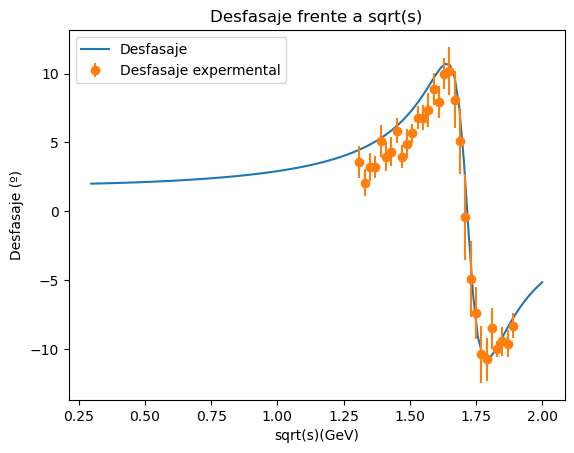

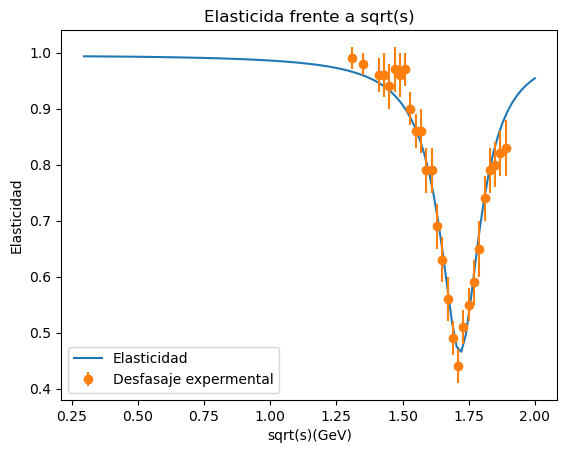

In [17]:
#2
rs=np.linspace(2*mpi,2,100)
plt.plot(rs,delta(rs**2,amin,bmin)*180/np.pi,label='Desfasaje')
plt.errorbar(edi,di,Ddi,fmt='o',label='Desfasaje expermental')
plt.title('Desfasaje frente a sqrt(s)')
plt.xlabel('sqrt(s)(GeV)')
plt.ylabel('Desfasaje (º)')
plt.legend()
plt.show()
plt.plot(rs,eta(rs**2,amin,bmin),label='Elasticidad')
plt.errorbar(eej,ej,Dej,fmt='o',label='Desfasaje expermental')
plt.title('Elasticida frente a sqrt(s)')
plt.xlabel('sqrt(s)(GeV)')
plt.ylabel('Elasticidad')
plt.legend()
plt.show()

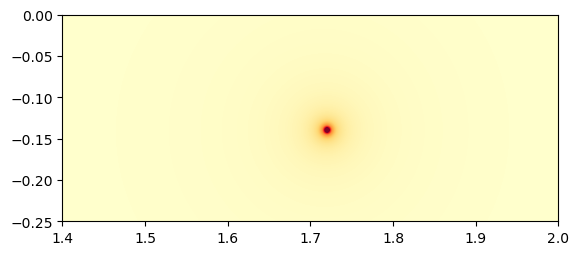

In [19]:
#3
Res=np.linspace(1.4,2,500)
Ims=np.linspace(-0.25,0,500)
Res,Ims=np.meshgrid(Res,Ims)
rs=Res+1j*Ims
plt.imshow(abs(t(rs**2,amin,bmin)),extent=[1.4,2,-0.25,0],vmax=10,cmap='YlOrRd')

In [21]:
#4
def t2(s,a,b):
    return 1/t(s,a,b)
def Re(s,a,b):
    return t2(s,a,b).real
def Im(s,a,b):
    return t2(s,a,b).imag

x0=1.7-0.15j
a=amin
b=bmin
rex=sol_nr(x0.real,Re,1e-6,a,b)
imx=sol_nr(x0.imag,Im,1e-6,a,b)
x=rex+imx*1j
Gamma=2*imx
m=rex
print('La masa es',m,'y la anchura',Gamma)

La masa es nan y la anchura 1.455043554853637


/tmp/ipykernel_1389/3291734405.py:54: RuntimeWarning: divide by zero encountered in scalar divide
  x=x0-f(x0,amin,bmin)/df(x0,f,h,amin,bmin)
/tmp/ipykernel_1389/3984357775.py:3: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/t(s,a,b)
/tmp/ipykernel_1389/3984357775.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return 1/t(s,a,b)
/tmp/ipykernel_1389/3291734405.py:49: RuntimeWarning: invalid value encountered in scalar subtract
  return (f(x0-h,amin,bmin)-f(x0+h,amin,bmin))/2/h


/tmp/ipykernel_1389/1715343222.py:8: RuntimeWarning: divide by zero encountered in divide
  return 1/sigma(s)*xro*b*a/(b**2-s-1j*b*a)
/tmp/ipykernel_1389/1715343222.py:10: RuntimeWarning: invalid value encountered in multiply
  return 1+2j*sigma(s)*t(s,a,b)


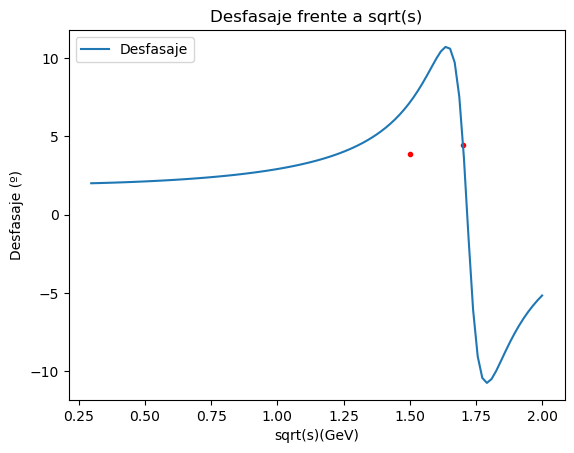

In [23]:
#5
def max_aurea(x1,x4,f):
    eps=10**-6
    z=(1+np.sqrt(5))/2
    x2=x4-(x4-x1)/z
    x3=x1+(x4-x1)/z
    err=1
    while err>eps:
        if f(x2)>=f(x3):
            x4=x3
            x3=x2
            x2=x4-(x4-x1)/z
        else:
            x1=x2
            x2=x3
            x3=x1+(x4-x1)/z
        err=abs(x4-x1)
    return (x2+x3)/2
def delta(s):
    return 0.5*np.arctan(S(s,a,b).imag/S(s,a,b).real)


rs=np.linspace(2*mpi,2,100)
min=min_aurea(1.5,1.6,delta)
max=max_aurea(1.6,1.7,delta)
plt.plot(min,delta(min)*180/np.pi,'r.')
plt.plot(max,delta(max)*180/np.pi,'r.')
def delta(s,a,b):
    return 0.5*np.arctan(S(s,a,b).imag/S(s,a,b).real)
    
plt.plot(rs,delta(rs**2,amin,bmin)*180/np.pi,label='Desfasaje')

plt.title('Desfasaje frente a sqrt(s)')
plt.xlabel('sqrt(s)(GeV)')
plt.ylabel('Desfasaje (º)')
plt.legend()
plt.show()